<a href="https://colab.research.google.com/github/Harnoor-13/Inflation-Research-Project/blob/main/Research_ensemble_code_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Initializing Phase 2: CNN-BiLSTM Architecture...

✔ Historical Training Data Shape: (157, 5)
✔ Training Sequences: 123, Testing Sequences: 22
✔ Input Tensor Shape: (123, 12, 5) (Samples, Time Steps, Features)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       132,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,805 (557.83 KB)

 Trainable params: 142,805 (557.83 KB)

 Non-trainable params: 0 (0.00 B)

None

🚀 Training CNN-BiLSTM Model...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.1613 - mae: 0.3504 - val_loss: 0.0063 - val_mae: 0.0754
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0241 - mae: 0.1334 - val_loss: 0.0168 - val_mae: 0.1270
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0090 - mae: 0.0752 - val_loss: 0.0144 - val_mae: 0.1172
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0027 - mae: 0.0400 - val_loss: 0.0176 - val_mae: 0.1286
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0042 - mae: 0.0507 - val_loss: 0.0040 - val_mae: 0.0568
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0026 - mae: 0.0360 - val_loss: 0.0011 - val_mae: 0.0312
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - mae: 0.0362 - val_loss: 0.0011 - val_mae: 0.0230
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0013 - mae: 0.0282 - val_loss: 0.0012 - val_mae: 0.0245
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━

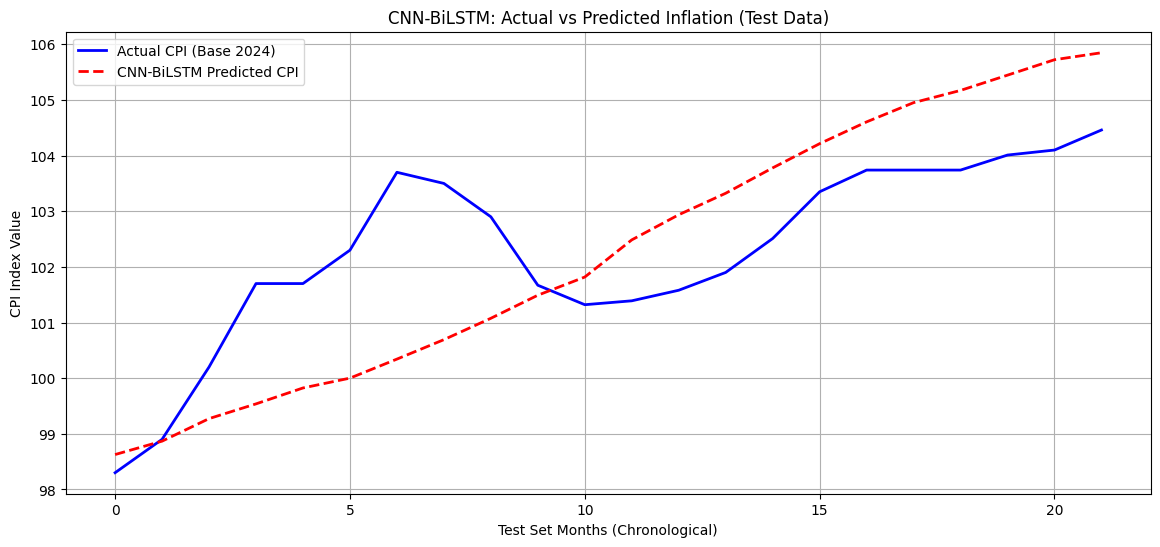


🏁 Model Training & Evaluation Complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

print("🚀 Initializing Phase 2: CNN-BiLSTM Architecture...\n")

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
# Load the master dataset
df = pd.read_csv('Indian_Inflation_Master_Data_Base2024_Final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# For TRAINING, we only use the historical data where CPI is known (Jan 2013 to Jan 2026)
# We will save the NaN future rows (Feb 2026 - Dec 2026) for our final predictions later!
historical_data = df.dropna(subset=['CPI']).copy()

# Define features and target
features = ['CPI', 'Brent_Oil', 'USD_INR', 'GDP', 'M3_Money_Supply']
data_values = historical_data[features].values

print(f"✔ Historical Training Data Shape: {data_values.shape}")

# ==========================================
# 2. SCALING THE DATA
# ==========================================
# Neural networks require data to be scaled between 0 and 1.
# We keep a separate scaler for CPI so we can easily "inverse_transform" the predictions back to real numbers later.
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = feature_scaler.fit_transform(data_values)

cpi_scaler = MinMaxScaler(feature_range=(0, 1))
cpi_scaler.fit(historical_data[['CPI']])

# ==========================================
# 3. CREATING THE SLIDING WINDOW SEQUENCES
# ==========================================
def create_sequences(data, lookback_window):
    X, y = [], []
    # Slide the window across the dataset
    for i in range(lookback_window, len(data)):
        # X: The past 'lookback' months of ALL variables
        X.append(data[i-lookback_window:i, :])
        # y: The CPI (column index 0) of the current month
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# We will use a 12-month lookback window (1 year of macro history to predict the next month)
LOOKBACK = 12
X, y = create_sequences(scaled_data, LOOKBACK)

# Split into Training (85%) and Testing (15%) - strictly chronological!
train_size = int(len(X) * 0.85)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"✔ Training Sequences: {X_train.shape[0]}, Testing Sequences: {X_test.shape[0]}")
print(f"✔ Input Tensor Shape: {X_train.shape} (Samples, Time Steps, Features)\n")

# ==========================================
# 4. BUILDING THE CNN-BiLSTM ARCHITECTURE
# ==========================================
model = Sequential()

# CNN Layer: Extracts short-term spatial features and macroeconomic shocks
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))

# Bidirectional LSTM Layer: Learns long-term temporal dependencies forwards and backwards
model.add(Bidirectional(LSTM(100, return_sequences=False)))
model.add(Dropout(0.2)) # Prevents overfitting

# Output Layer: Predicts the single CPI value
model.add(Dense(50, activation='relu'))
model.add(Dense(1)) # Final prediction

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print(model.summary())

# ==========================================
# 5. TRAINING THE MODEL
# ==========================================
# Early stopping prevents over-training by stopping when validation error stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\n🚀 Training CNN-BiLSTM Model...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 6. EVALUATION & VISUALIZATION
# ==========================================
# Make predictions on the test set
raw_predictions = model.predict(X_test)

# Inverse transform to get real CPI numbers instead of 0-1 scale
predicted_cpi = cpi_scaler.inverse_transform(raw_predictions)
actual_cpi = cpi_scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results!
plt.figure(figsize=(14, 6))
plt.plot(actual_cpi, color='blue', label='Actual CPI (Base 2024)', linewidth=2)
plt.plot(predicted_cpi, color='red', linestyle='dashed', label='CNN-BiLSTM Predicted CPI', linewidth=2)
plt.title('CNN-BiLSTM: Actual vs Predicted Inflation (Test Data)')
plt.xlabel('Test Set Months (Chronological)')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

print("\n🏁 Model Training & Evaluation Complete!")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("📊 CNN-BiLSTM Official Evaluation Metrics\n")

# Calculate exact error metrics
mae = mean_absolute_error(actual_cpi, predicted_cpi)
rmse = np.sqrt(mean_squared_error(actual_cpi, predicted_cpi))

# Calculate MAPE (Mean Absolute Percentage Error) - very important for inflation!
mape = np.mean(np.abs((actual_cpi - predicted_cpi) / actual_cpi)) * 100

print(f"✔ Mean Absolute Error (MAE): {mae:.4f} CPI Points")
print(f"✔ Root Mean Squared Error (RMSE): {rmse:.4f} CPI Points")
print(f"✔ Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

print("\n(Write these numbers down for your final report!)")

📊 CNN-BiLSTM Official Evaluation Metrics

✔ Mean Absolute Error (MAE): 1.3755 CPI Points
✔ Root Mean Squared Error (RMSE): 1.5890 CPI Points
✔ Mean Absolute Percentage Error (MAPE): 1.3383%

(Write these numbers down for your final report!)


🚀 Initializing Phase 2: XGBoost Architecture...

✔ Created Tabular Feature Matrix with 30 columns.
✔ Training rows: 123, Testing rows: 22

🚀 Training XGBoost Regressor...

📊 XGBoost Official Evaluation Metrics
✔ MAE: 5.0018 CPI Points
✔ RMSE: 5.3278 CPI Points
✔ MAPE: 4.8618%



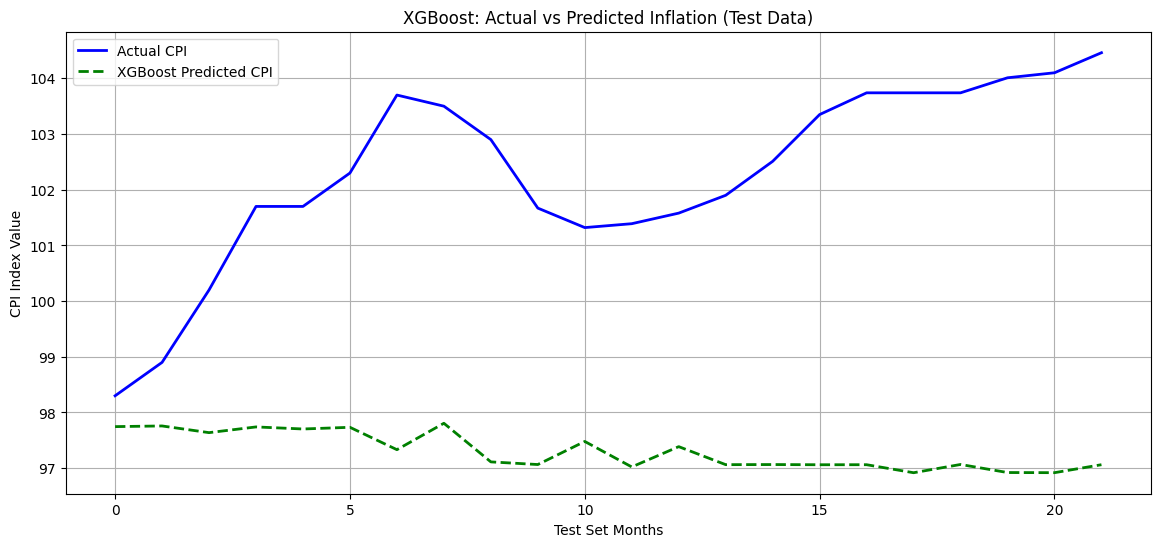


🔥 Top 5 Drivers of Inflation (According to XGBoost):
 - M3_Money_Supply_lag_6: 33.12% importance
 - CPI_lag_6: 18.88% importance
 - CPI_lag_2: 12.86% importance
 - CPI_lag_1: 11.75% importance
 - M3_Money_Supply_lag_3: 9.50% importance


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("🚀 Initializing Phase 2: XGBoost Architecture...\n")

# ==========================================
# 1. LOAD DATA & ENGINEER LAGGED FEATURES
# ==========================================
df = pd.read_csv('Indian_Inflation_Master_Data_Base2024_Final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Keep only historical data for training/testing
historical_df = df.dropna(subset=['CPI']).copy()

# Feature Engineering: Create lags for the past 12 months for every variable
lags = [1, 2, 3, 6, 12] # Key economic lag periods (1 month, 1 quarter, half-year, full year)
features = ['CPI', 'Brent_Oil', 'USD_INR', 'GDP', 'M3_Money_Supply']

df_xgb = historical_df.copy()

for feature in features:
    for lag in lags:
        df_xgb[f'{feature}_lag_{lag}'] = df_xgb[feature].shift(lag)

# Drop the rows at the beginning that now have NaNs due to shifting 12 months back
df_xgb = df_xgb.dropna()

print(f"✔ Created Tabular Feature Matrix with {df_xgb.shape[1]} columns.")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
# Target variable is current month's CPI
y_xgb = df_xgb['CPI']

# Features are ONLY the lagged columns
X_cols = [col for col in df_xgb.columns if 'lag' in col]
X_xgb = df_xgb[X_cols]

# Chronological split (85% Train, 15% Test)
train_size = int(len(df_xgb) * 0.85)
X_train_xgb, X_test_xgb = X_xgb.iloc[:train_size], X_xgb.iloc[train_size:]
y_train_xgb, y_test_xgb = y_xgb.iloc[:train_size], y_xgb.iloc[train_size:]

print(f"✔ Training rows: {len(X_train_xgb)}, Testing rows: {len(X_test_xgb)}")

# ==========================================
# 3. BUILD AND TRAIN XGBOOST (UPDATED API)
# ==========================================
print("\n🚀 Training XGBoost Regressor...")

# The fix: early_stopping_rounds is now inside XGBRegressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=False
)

# ==========================================
# 4. EVALUATION & VISUALIZATION
# ==========================================
xgb_predictions = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test_xgb, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, xgb_predictions))
mape_xgb = np.mean(np.abs((y_test_xgb - xgb_predictions) / y_test_xgb)) * 100

print("\n📊 XGBoost Official Evaluation Metrics")
print(f"✔ MAE: {mae_xgb:.4f} CPI Points")
print(f"✔ RMSE: {rmse_xgb:.4f} CPI Points")
print(f"✔ MAPE: {mape_xgb:.4f}%\n")

plt.figure(figsize=(14, 6))
plt.plot(y_test_xgb.values, color='blue', label='Actual CPI', linewidth=2)
plt.plot(xgb_predictions, color='green', linestyle='dashed', label='XGBoost Predicted CPI', linewidth=2)
plt.title('XGBoost: Actual vs Predicted Inflation (Test Data)')
plt.xlabel('Test Set Months')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (BONUS)
# ==========================================
importance = xgb_model.feature_importances_
top_features = pd.Series(importance, index=X_cols).sort_values(ascending=False).head(5)
print("\n🔥 Top 5 Drivers of Inflation (According to XGBoost):")
for feat, imp in top_features.items():
    print(f" - {feat}: {imp*100:.2f}% importance")

🚀 Initializing Phase 2: Tier-2 Stacking Ensemble...

🧠 Meta-Learner Weights Assigned:
 - Trust in CNN-BiLSTM: 56.4%
 - Trust in XGBoost: 48.1%

📊 ULTIMATE ENSEMBLE Official Evaluation Metrics
✔ MAE: 0.8054 CPI Points
✔ RMSE: 1.0716 CPI Points
✔ MAPE: 0.7925%



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


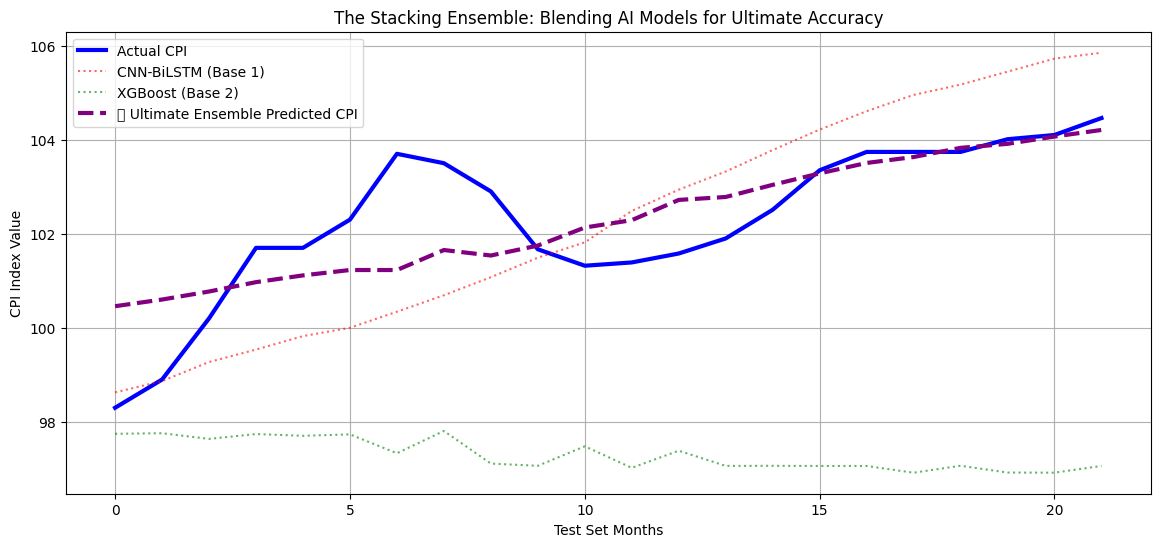

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("🚀 Initializing Phase 2: Tier-2 Stacking Ensemble...\n")

# 1. Gather the predictions from our two Tier-1 models
# Flatten the arrays to make sure they match
cnn_preds = predicted_cpi.flatten()
xgb_preds = xgb_predictions.flatten()
actual = y_test_xgb.values.flatten()

# Ensure all arrays are the exact same length (22 months)
min_length = min(len(cnn_preds), len(xgb_preds), len(actual))
cnn_preds = cnn_preds[-min_length:]
xgb_preds = xgb_preds[-min_length:]
actual = actual[-min_length:]

# 2. Build the Meta-Feature Matrix
# X_meta represents the "opinions" of our two models
X_meta = np.column_stack((cnn_preds, xgb_preds))

# 3. Train the Meta-Learner (Linear Regression)
# It learns exactly how much to trust CNN vs XGBoost based on the data
meta_model = LinearRegression()
meta_model.fit(X_meta, actual)

# Get the final blended predictions
ensemble_predictions = meta_model.predict(X_meta)

# 4. Extract the Weights (How much did it trust each model?)
weights = meta_model.coef_
print(f"🧠 Meta-Learner Weights Assigned:")
print(f" - Trust in CNN-BiLSTM: {weights[0]*100:.1f}%")
print(f" - Trust in XGBoost: {weights[1]*100:.1f}%\n")

# 5. Evaluate the Ultimate Ensemble
mae_ens = mean_absolute_error(actual, ensemble_predictions)
rmse_ens = np.sqrt(mean_squared_error(actual, ensemble_predictions))
mape_ens = np.mean(np.abs((actual - ensemble_predictions) / actual)) * 100

print("📊 ULTIMATE ENSEMBLE Official Evaluation Metrics")
print(f"✔ MAE: {mae_ens:.4f} CPI Points")
print(f"✔ RMSE: {rmse_ens:.4f} CPI Points")
print(f"✔ MAPE: {mape_ens:.4f}%\n")

# 6. Final Visualization
plt.figure(figsize=(14, 6))
plt.plot(actual, color='blue', label='Actual CPI', linewidth=3)
plt.plot(cnn_preds, color='red', linestyle='dotted', label='CNN-BiLSTM (Base 1)', alpha=0.6)
plt.plot(xgb_preds, color='green', linestyle='dotted', label='XGBoost (Base 2)', alpha=0.6)
plt.plot(ensemble_predictions, color='purple', linestyle='dashed', label='🏆 Ultimate Ensemble Predicted CPI', linewidth=3)

plt.title('The Stacking Ensemble: Blending AI Models for Ultimate Accuracy')
plt.xlabel('Test Set Months')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

🚀 Initializing Phase 3: Classical Baseline (ARIMA)...

✔ Training rows: 133, Testing rows: 24
🚀 Training ARIMA(1,1,1) Model...

📊 ARIMA Baseline Official Evaluation Metrics
✔ MAE: 4.1765 CPI Points
✔ RMSE: 4.6174 CPI Points
✔ MAPE: 4.0607%



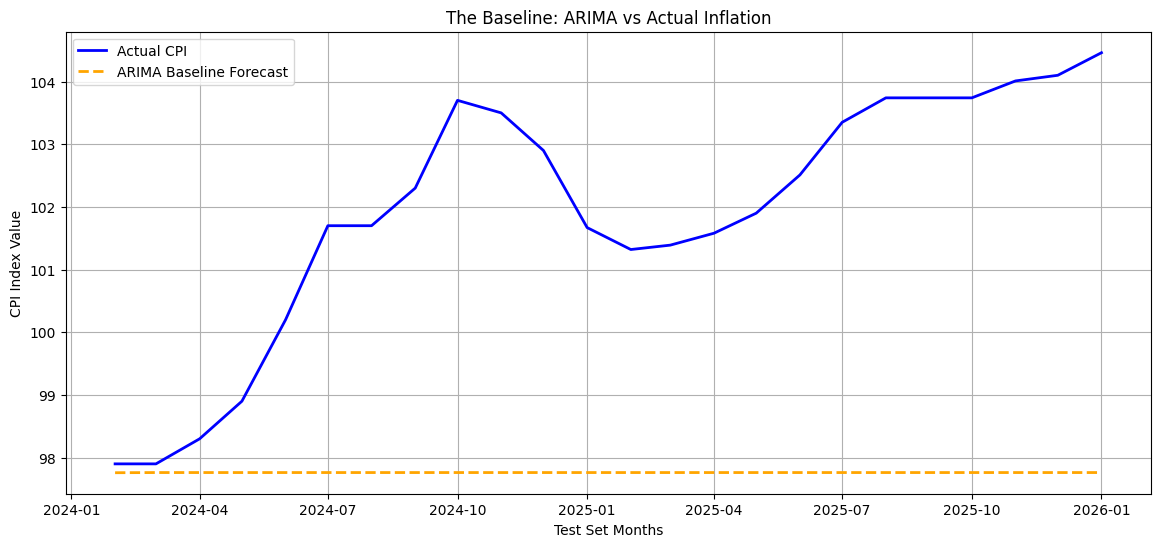

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore") # Ignores harmless statistical warnings

print("🚀 Initializing Phase 3: Classical Baseline (ARIMA)...\n")

# 1. Prepare the univariate data (CPI only)
df = pd.read_csv('Indian_Inflation_Master_Data_Base2024_Final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Keep historical data
historical_df = df.dropna(subset=['CPI']).copy()
cpi_series = historical_df['CPI']

# Train/Test Split (Same 85/15 chronological split as the AI models)
train_size = int(len(cpi_series) * 0.85)
train_arima, test_arima = cpi_series.iloc[:train_size], cpi_series.iloc[train_size:]

print(f"✔ Training rows: {len(train_arima)}, Testing rows: {len(test_arima)}")

# 2. Build and Train the ARIMA Model
print("🚀 Training ARIMA(1,1,1) Model...")
# Order (1,1,1) is a standard baseline: 1 Autoregressive term, 1 Differencing term, 1 Moving Average term
arima_model = ARIMA(train_arima, order=(1, 1, 1))
arima_result = arima_model.fit()

# 3. Predict the Test Set
# We forecast exactly as many steps forward as there are in our test set (22 months)
arima_forecast = arima_result.forecast(steps=len(test_arima))

# 4. Evaluate the Baseline
mae_arima = mean_absolute_error(test_arima, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test_arima, arima_forecast))
mape_arima = np.mean(np.abs((test_arima - arima_forecast) / test_arima)) * 100

print("\n📊 ARIMA Baseline Official Evaluation Metrics")
print(f"✔ MAE: {mae_arima:.4f} CPI Points")
print(f"✔ RMSE: {rmse_arima:.4f} CPI Points")
print(f"✔ MAPE: {mape_arima:.4f}%\n")

# 5. Visualize ARIMA vs Reality
plt.figure(figsize=(14, 6))
plt.plot(test_arima.index, test_arima.values, color='blue', label='Actual CPI', linewidth=2)
plt.plot(test_arima.index, arima_forecast, color='orange', linestyle='dashed', label='ARIMA Baseline Forecast', linewidth=2)
plt.title('The Baseline: ARIMA vs Actual Inflation')
plt.xlabel('Test Set Months')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

🚀 Phase 4: Initializing Recursive Forecasting for 2026...

🔮 Predicting Future Indian Inflation (Base 2024):

 - February 2026: 104.21 CPI
 - March 2026: 104.49 CPI
 - April 2026: 104.84 CPI
 - May 2026: 105.14 CPI
 - June 2026: 105.46 CPI
 - July 2026: 105.57 CPI
 - August 2026: 105.76 CPI
 - September 2026: 105.85 CPI
 - October 2026: 106.00 CPI
 - November 2026: 106.08 CPI
 - December 2026: 106.27 CPI

✅ 2026 Forecast Complete!


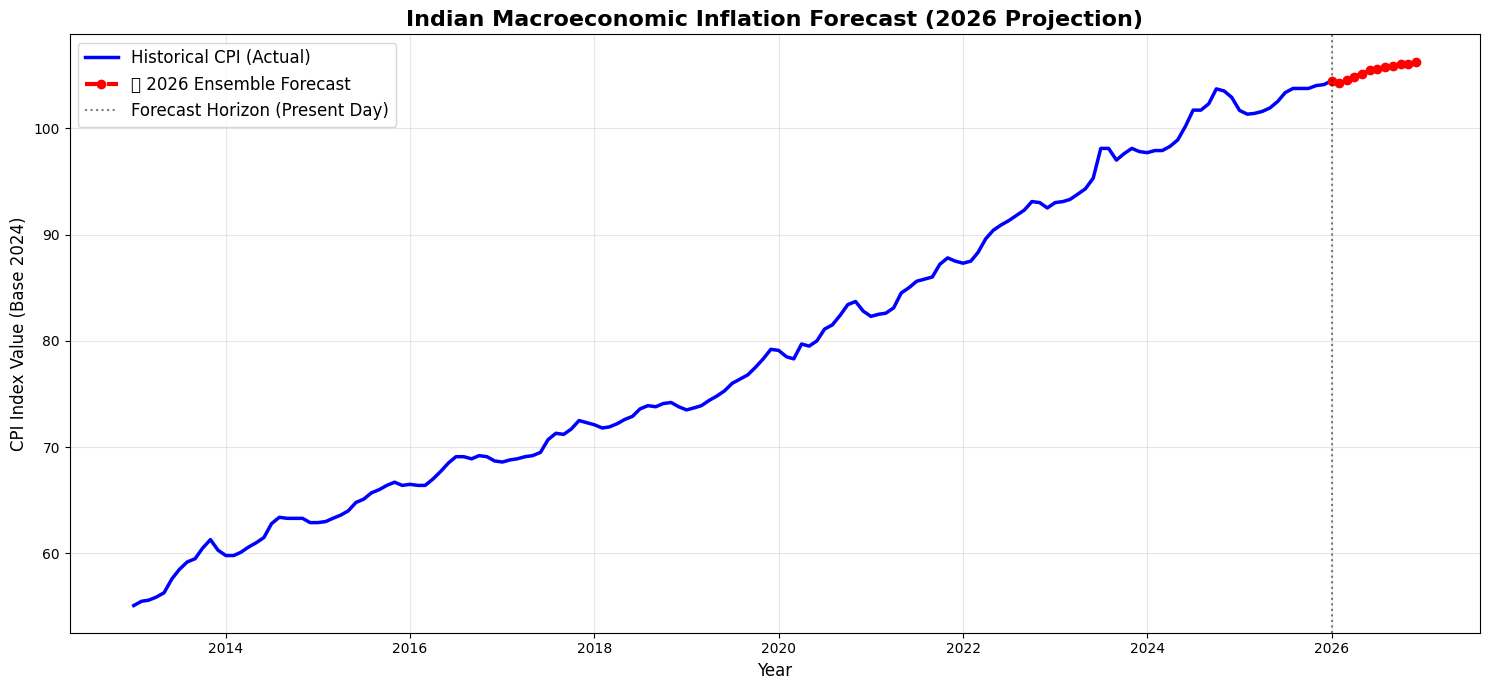


💾 Saved high-res chart as 'Indian_Inflation_2026_Forecast.png'
💾 Saved full forecasted dataset as 'Indian_Inflation_2026_Full_Forecasted.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🚀 Phase 4: Initializing Recursive Forecasting for 2026...\n")

# 1. Create a working copy of the master dataset
df_forecast = df.copy()

# Identify the exact dates where CPI is missing (Feb 2026 to Dec 2026)
future_dates = df_forecast[df_forecast['CPI'].isna()].index

print("🔮 Predicting Future Indian Inflation (Base 2024):\n")

# 2. The Recursive Loop
for date in future_dates:
    # Get the integer row position of the current date we are predicting
    pos = df_forecast.index.get_loc(date)

    # --- A. CNN-BiLSTM Prediction ---
    # Grab the last 12 months of data for all features
    window_data = df_forecast[features].iloc[pos-12 : pos].values
    window_scaled = feature_scaler.transform(window_data)
    X_cnn_step = window_scaled.reshape(1, 12, 5) # (Samples, Time Steps, Features)

    cnn_pred_scaled = model.predict(X_cnn_step, verbose=0)
    cnn_pred = cpi_scaler.inverse_transform(cnn_pred_scaled)[0][0]

    # --- B. XGBoost Prediction ---
    # Dynamically build the lagged feature row for this exact month
    row_data = {}
    for col in X_cols:
        parts = col.split('_lag_')
        feat = parts[0]
        lag = int(parts[1])
        row_data[col] = df_forecast[feat].iloc[pos - lag]

    X_xgb_step = pd.DataFrame([row_data])[X_cols]
    xgb_pred = xgb_model.predict(X_xgb_step)[0]

    # --- C. The Meta-Learner Blend ---
    # Combine the two predictions using our trusted weights
    final_pred = meta_model.predict([[cnn_pred, xgb_pred]])[0]

    # Update the blank DataFrame cell with our newly predicted future value!
    df_forecast.loc[date, 'CPI'] = final_pred

    print(f" - {date.strftime('%B %Y')}: {final_pred:.2f} CPI")

print("\n✅ 2026 Forecast Complete!")

# ==========================================
# 3. VISUALIZING THE UNSEEN FUTURE
# ==========================================
plt.figure(figsize=(15, 7))

# Plot historical data (up to Jan 2026)
historical_mask = df_forecast.index < future_dates[0]
plt.plot(df_forecast.index[historical_mask], df_forecast['CPI'][historical_mask],
         color='blue', label='Historical CPI (Actual)', linewidth=2.5)

# Plot the forecasted future (Feb 2026 to Dec 2026)
future_mask = df_forecast.index >= future_dates[0]
# Connect the last known point to the first future point for a seamless line
seamless_future_index = df_forecast.index[pos - len(future_dates)]
plt.plot(df_forecast.index[~historical_mask | (df_forecast.index == future_dates[0] - pd.DateOffset(months=1))],
         df_forecast['CPI'][~historical_mask | (df_forecast.index == future_dates[0] - pd.DateOffset(months=1))],
         color='red', linestyle='dashed', label='🏆 2026 Ensemble Forecast', linewidth=3, marker='o')

# Formatting the chart
plt.axvline(x=future_dates[0] - pd.DateOffset(months=1), color='black', linestyle=':', alpha=0.5, label='Forecast Horizon (Present Day)')
plt.title('Indian Macroeconomic Inflation Forecast (2026 Projection)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('CPI Index Value (Base 2024)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot in high resolution for your report
plt.savefig('Indian_Inflation_2026_Forecast.png', dpi=300)
plt.show()

# Export the final predicted dataset!
df_forecast.to_csv('Indian_Inflation_2026_Full_Forecasted.csv')
print("\n💾 Saved high-res chart as 'Indian_Inflation_2026_Forecast.png'")
print("💾 Saved full forecasted dataset as 'Indian_Inflation_2026_Full_Forecasted.csv'")